# EDA Khusus — Aksara Jawa

Dataset Jawa di repo ini punya **dua sub-folder** yang fungsinya berbeda:

| Sub-folder | Struktur | Isi |
|------------|----------|-----|
| `all_class/` | `Vokal X / konsonan / *.png` | Dataset utama — kombinasi vokal × konsonan (mirip Sunda) |
| `variations/` | `konsonan / *.jpg` | Variasi gaya tulisan untuk **8 konsonan terpilih** (tanpa info vokal) |

Notebook ini explore keduanya: distribusi, heatmap, dimensi citra, contoh visual, dan perbandingan.

In [1]:
import os
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style('whitegrid')

JAWA_ROOT = Path.cwd() / 'Indonesian Local Script Characters' / 'Indonesian Local Script Characters' / 'Jawa' / 'Jawa'
ALL_CLASS = JAWA_ROOT / 'all_class'
VARIATIONS = JAWA_ROOT / 'variations'
OUT_DIR = Path.cwd() / 'results_jawa_eda'
OUT_DIR.mkdir(exist_ok=True)

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp'}

assert ALL_CLASS.exists() and VARIATIONS.exists(), 'Folder Jawa tidak ditemukan.'
print('Root      :', JAWA_ROOT)
print('all_class :', ALL_CLASS)
print('variations:', VARIATIONS)
print('Output    :', OUT_DIR)

Root      : d:\Doc-Coolyeah\00-AKADEMIK\SMT-6-Sem6\Proposal\Indonesian Local Script Characters\Indonesian Local Script Characters\Jawa\Jawa
all_class : d:\Doc-Coolyeah\00-AKADEMIK\SMT-6-Sem6\Proposal\Indonesian Local Script Characters\Indonesian Local Script Characters\Jawa\Jawa\all_class
variations: d:\Doc-Coolyeah\00-AKADEMIK\SMT-6-Sem6\Proposal\Indonesian Local Script Characters\Indonesian Local Script Characters\Jawa\Jawa\variations
Output    : d:\Doc-Coolyeah\00-AKADEMIK\SMT-6-Sem6\Proposal\results_jawa_eda


## 1. Inventaris cepat

Berapa vokal, berapa konsonan di tiap sub-dataset?

In [2]:
vowel_dirs = sorted([p for p in ALL_CLASS.iterdir() if p.is_dir()])
print(f'all_class — {len(vowel_dirs)} vokal:')
for v in vowel_dirs:
    cons = sorted([p.name for p in v.iterdir() if p.is_dir()])
    print(f'  {v.name:10s}  ({len(cons)} konsonan)  contoh: {cons[:6]}...')

var_dirs = sorted([p.name for p in VARIATIONS.iterdir() if p.is_dir()])
print(f'\nvariations — {len(var_dirs)} konsonan: {var_dirs}')

all_class — 6 vokal:
  Vokal A     (20 konsonan)  contoh: ['ba', 'ca', 'da', 'dha', 'ga', 'ha']...
  Vokal E     (20 konsonan)  contoh: ['be', 'ce', 'de', 'dhe', 'ge', 'he']...
  Vokal I     (20 konsonan)  contoh: ['bi', 'ci', 'dhi', 'di', 'gi', 'hi']...
  Vokal O     (20 konsonan)  contoh: ['bo', 'co', 'dho', 'do', 'go', 'ho']...
  Vokal U     (20 konsonan)  contoh: ['bu', 'cu', 'dhu', 'du', 'gu', 'hu']...
  Vokal È     (20 konsonan)  contoh: ['bè', 'cè', 'dhè', 'dè', 'gè', 'hè']...

variations — 8 konsonan: ['ba', 'ga', 'ha', 'ka', 'la', 'nya', 'ra', 'ta']


## 2. Scan & normalisasi nama konsonan

Tiap folder vokal punya konsonan ber-suffix vokal (`Ba` di `Vokal A`, `Be` di `Vokal E`, dst.). Kita strip suffix biar bisa di-pivot ke matriks konsonan × vokal.

In [3]:
# Urutan terpanjang dulu — vital agar 'eu', 'è' tidak salah strip
VOWEL_SUFFIXES = ['eu', 'è', 'a', 'e', 'i', 'o', 'u']

def strip_vowel(name: str, vowel: str) -> str:
    s = name.lower()
    # urutan: coba suffix vokal aktual dulu
    candidates = [vowel.lower()] + [v for v in VOWEL_SUFFIXES if v != vowel.lower()]
    for suf in candidates:
        if s.endswith(suf) and len(s) > len(suf):
            return s[: -len(suf)]
    return s

def count_imgs(folder: Path) -> int:
    return sum(1 for f in folder.iterdir() if f.suffix.lower() in IMG_EXT)

rows = []
for v in vowel_dirs:
    vowel_name = v.name.replace('Vokal ', '').strip()  # 'A', 'E', ...
    for c in sorted([p for p in v.iterdir() if p.is_dir()]):
        consonant = strip_vowel(c.name, vowel_name)
        n = count_imgs(c)
        rows.append({'vowel': vowel_name, 'consonant_raw': c.name,
                     'consonant': consonant, 'count': n})

df_all = pd.DataFrame(rows)
df_all.to_csv(OUT_DIR / 'all_class_per_class.csv', index=False)
print(f'all_class — total kelas: {len(df_all)}, total citra: {df_all["count"].sum():,}')
df_all.head(12)

all_class — total kelas: 120, total citra: 12,191


,vowel,consonant_raw,consonant,count
0,A,ba,b,468
1,A,ca,c,599
2,A,da,d,603
3,A,dha,dh,606
4,A,ga,g,487
5,A,ha,h,426
6,A,ja,j,611
7,A,ka,k,436
8,A,la,l,437
9,A,ma,m,608


In [4]:
var_rows = []
for c in sorted([p for p in VARIATIONS.iterdir() if p.is_dir()]):
    var_rows.append({'consonant': c.name, 'count': count_imgs(c)})
df_var = pd.DataFrame(var_rows).sort_values('count', ascending=False).reset_index(drop=True)
df_var.to_csv(OUT_DIR / 'variations_per_class.csv', index=False)
print(f'variations — {len(df_var)} konsonan, total citra: {df_var["count"].sum():,}')
df_var

variations — 8 konsonan, total citra: 1,066


,consonant,count
0,ka,175
1,nya,155
2,ra,150
3,ta,143
4,la,133
5,ga,126
6,ha,123
7,ba,61


## 3. Distribusi `all_class`

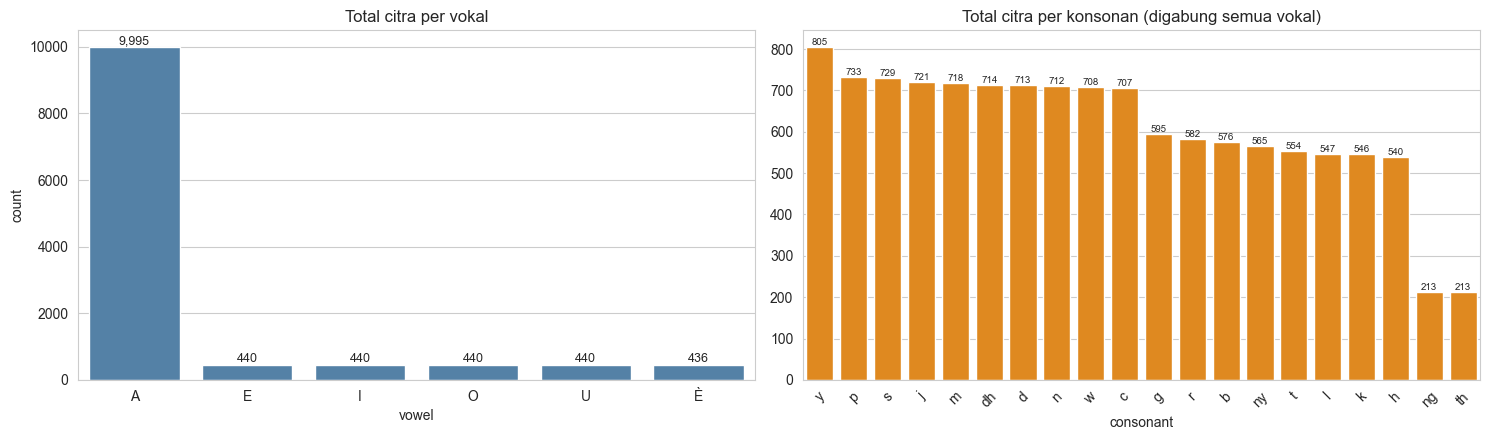

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

by_vowel = df_all.groupby('vowel')['count'].sum().sort_values(ascending=False)
sns.barplot(x=by_vowel.index, y=by_vowel.values, ax=axes[0], color='steelblue')
axes[0].set_title('Total citra per vokal')
axes[0].set_ylabel('count')
for i, v in enumerate(by_vowel.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

by_cons = df_all.groupby('consonant')['count'].sum().sort_values(ascending=False)
sns.barplot(x=by_cons.index, y=by_cons.values, ax=axes[1], color='darkorange')
axes[1].set_title('Total citra per konsonan (digabung semua vokal)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(by_cons.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'all_class_by_axis.png', dpi=120)
plt.show()

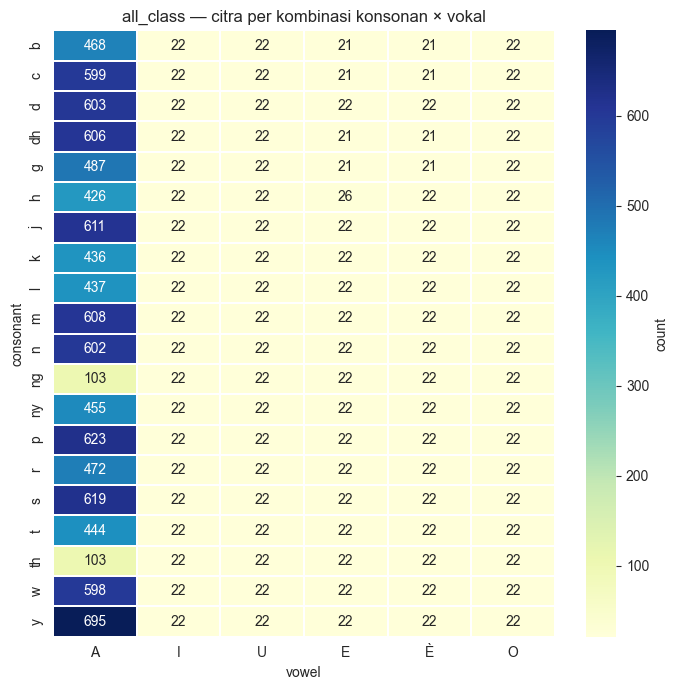

Sel dengan count = 0 (kombinasi yang hilang): []


In [6]:
# Heatmap konsonan × vokal
mat = df_all.pivot(index='consonant', columns='vowel', values='count').fillna(0).astype(int)
vowel_order = ['A', 'I', 'U', 'E', 'È', 'O']
mat = mat.reindex(columns=[v for v in vowel_order if v in mat.columns])

fig, ax = plt.subplots(figsize=(7, max(6, 0.35 * len(mat))))
sns.heatmap(mat, annot=True, fmt='d', cmap='YlGnBu',
            cbar_kws={'label': 'count'}, linewidths=0.3, linecolor='white', ax=ax)
ax.set_title('all_class — citra per kombinasi konsonan × vokal')
plt.tight_layout()
plt.savefig(OUT_DIR / 'all_class_heatmap.png', dpi=120)
plt.show()

print('Sel dengan count = 0 (kombinasi yang hilang):',
      [(c, v) for c in mat.index for v in mat.columns if mat.loc[c, v] == 0])

In [7]:
# Statistik all_class
vals = df_all['count'].values
print(f'Jumlah kelas (kombinasi)  : {len(vals)}')
print(f'Total citra               : {vals.sum():,}')
print(f'Mean / median per kelas   : {vals.mean():.2f} / {np.median(vals):.1f}')
print(f'Std                       : {vals.std():.2f}')
print(f'Min / Max                 : {vals.min()} / {vals.max()}')
print(f'Imbalance ratio (max/min) : {vals.max()/vals.min():.2f}x')
print()
print('5 kelas terkecil:')
print(df_all.nsmallest(5, 'count')[['vowel', 'consonant', 'count']].to_string(index=False))
print('\n5 kelas terbesar:')
print(df_all.nlargest(5, 'count')[['vowel', 'consonant', 'count']].to_string(index=False))

Jumlah kelas (kombinasi)  : 120
Total citra               : 12,191
Mean / median per kelas   : 101.59 / 22.0
Std                       : 188.94
Min / Max                 : 21 / 695
Imbalance ratio (max/min) : 33.10x

5 kelas terkecil:
vowel consonant  count
    E         b     21
    E         c     21
    E        dh     21
    E         g     21
    È         b     21

5 kelas terbesar:
vowel consonant  count
    A         y    695
    A         p    623
    A         s    619
    A         j    611
    A         m    608


## 4. Distribusi `variations`

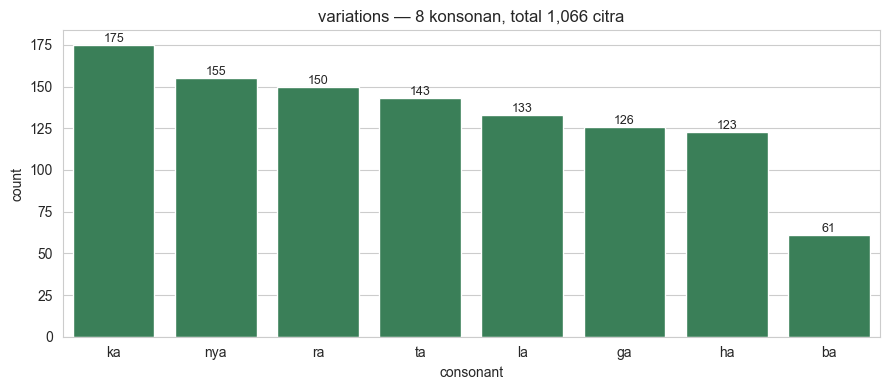

Imbalance ratio variations: 2.87x


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=df_var, x='consonant', y='count', ax=ax, color='seagreen')
ax.set_title(f'variations — {len(df_var)} konsonan, total {df_var["count"].sum():,} citra')
for i, v in enumerate(df_var['count']):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'variations_distribution.png', dpi=120)
plt.show()

print(f'Imbalance ratio variations: {df_var["count"].max() / df_var["count"].min():.2f}x')

## 5. Dimensi citra & properti file

Berapa ukuran rata-rata, ada anomali ukuran/format?

In [9]:
import random
random.seed(42)

def sample_props(folder: Path, k: int = 60):
    files = [f for f in folder.rglob('*') if f.suffix.lower() in IMG_EXT]
    if not files:
        return []
    picks = random.sample(files, k=min(k, len(files)))
    out = []
    for f in picks:
        try:
            with Image.open(f) as im:
                out.append({
                    'subset': folder.name,
                    'path': str(f.relative_to(JAWA_ROOT)),
                    'width': im.size[0],
                    'height': im.size[1],
                    'mode': im.mode,
                    'format': im.format,
                    'kb': round(f.stat().st_size / 1024, 1),
                })
        except Exception as e:
            out.append({'subset': folder.name, 'path': str(f), 'error': str(e)})
    return out

props = sample_props(ALL_CLASS, 200) + sample_props(VARIATIONS, 100)
df_props = pd.DataFrame(props)
print('Sample size:', len(df_props))
print('\nMode (channel) distribution:')
print(df_props['mode'].value_counts())
print('\nFormat distribution:')
print(df_props['format'].value_counts())
df_props.head()

Sample size: 300

Mode (channel) distribution:
mode
RGB     295
RGBA      5
Name: count, dtype: int64

Format distribution:
format
JPEG    274
PNG      26
Name: count, dtype: int64


,subset,path,width,height,mode,format,kb
0,all_class,all_class\Vokal A\ta\ta (208).png,362,347,RGB,JPEG,6.1
1,all_class,all_class\Vokal E\dhe\dhe1.jpg,343,241,RGB,JPEG,9.3
2,all_class,all_class\Vokal È\wè\w`e21.jpg,279,289,RGB,JPEG,7.5
3,all_class,all_class\Vokal A\ya\ya (684).png,202,122,RGB,PNG,20.4
4,all_class,all_class\Vokal A\ga\ga (126).png,362,347,RGB,JPEG,6.6


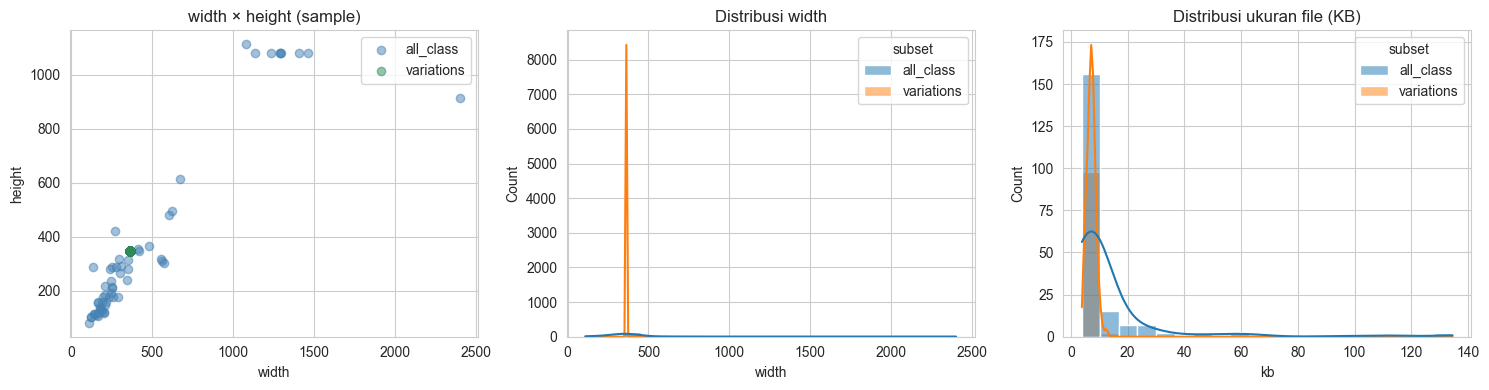


Ukuran umum (modus):
subset      width  height
all_class   363    347       42
                   348       41
            362    348       31
variations  363    348       38
            362    347       33
                   348       15
dtype: int64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for sub, color in [('all_class', 'steelblue'), ('variations', 'seagreen')]:
    d = df_props[df_props['subset'] == sub]
    axes[0].scatter(d['width'], d['height'], alpha=0.5, label=sub, color=color)
axes[0].set_title('width × height (sample)')
axes[0].set_xlabel('width'); axes[0].set_ylabel('height')
axes[0].legend()

sns.histplot(data=df_props, x='width', hue='subset', kde=True, ax=axes[1], bins=20)
axes[1].set_title('Distribusi width')

sns.histplot(data=df_props, x='kb', hue='subset', kde=True, ax=axes[2], bins=20)
axes[2].set_title('Distribusi ukuran file (KB)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'image_properties.png', dpi=120)
plt.show()

print('\nUkuran umum (modus):')
common_size = df_props.groupby('subset').apply(
    lambda d: d.groupby(['width', 'height']).size().sort_values(ascending=False).head(3)
)
print(common_size)

## 6. Galeri visual — `all_class`

Satu contoh per (vokal × konsonan), supaya kelihatan rupa aksara di tiap kombinasi.

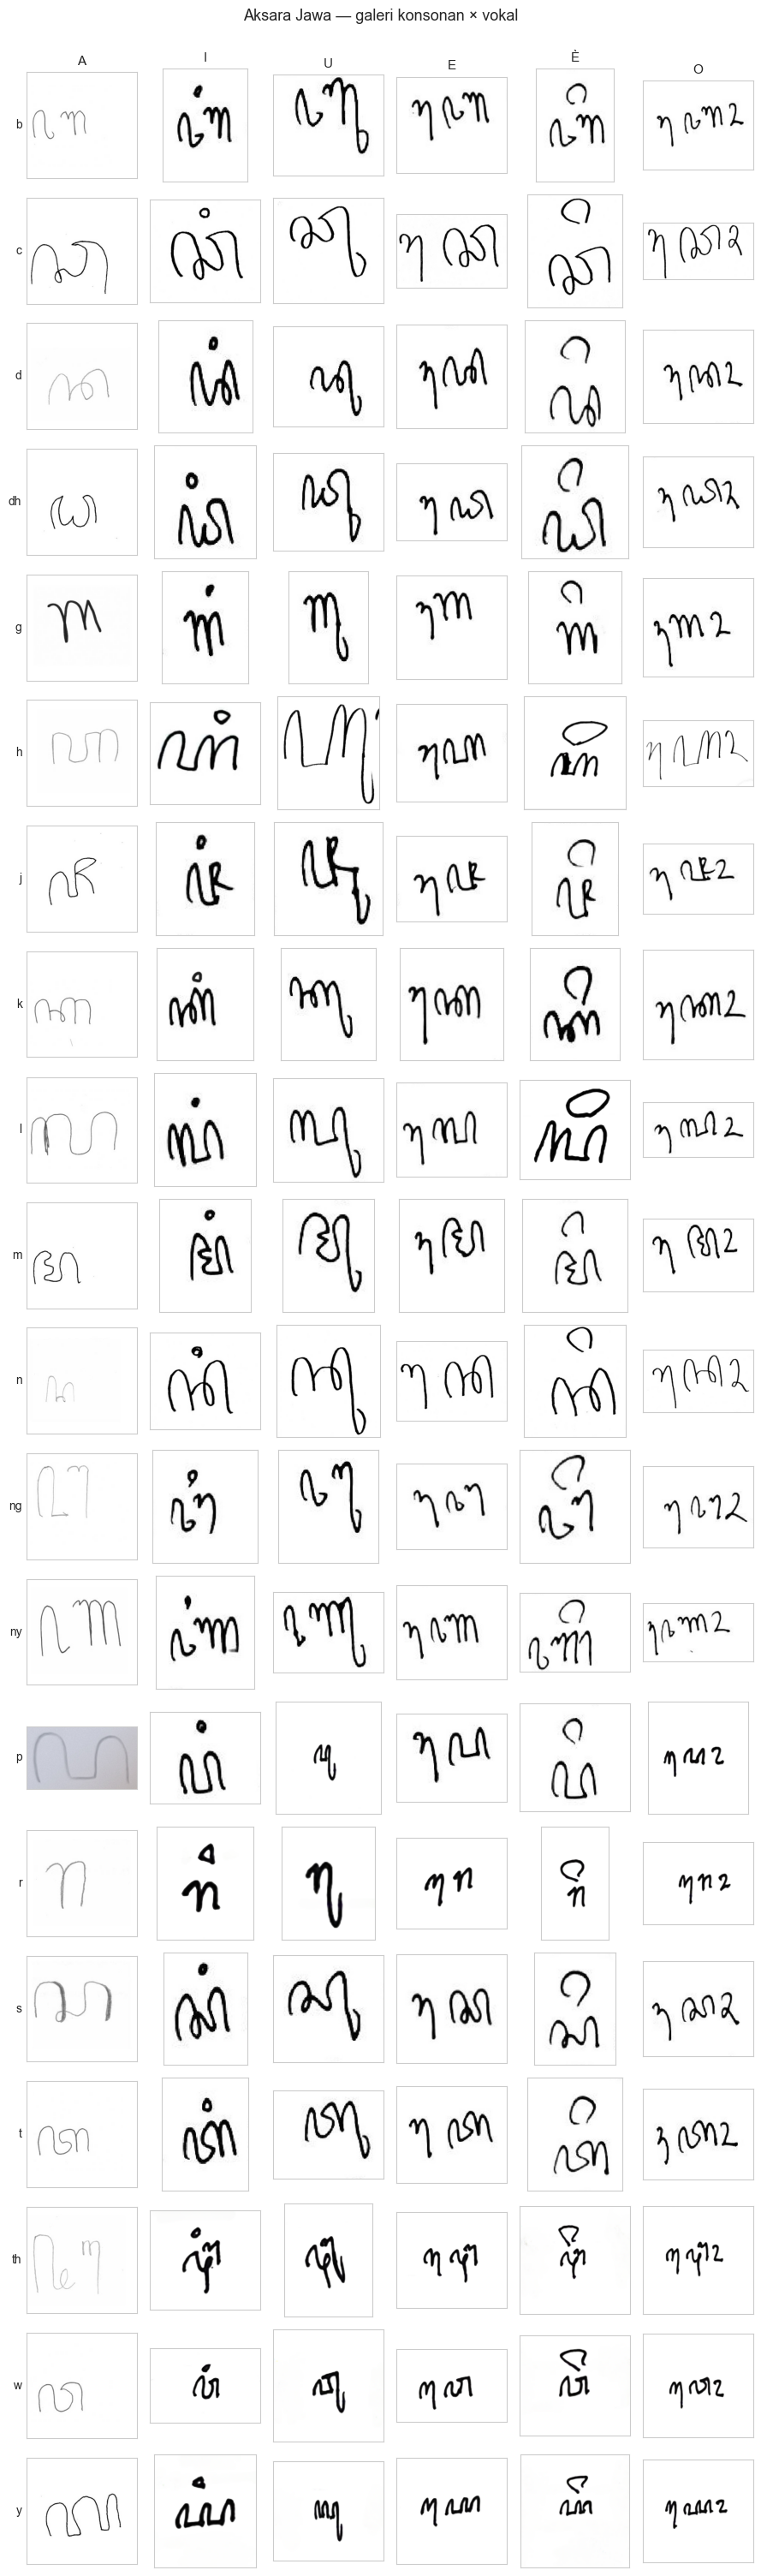

In [11]:
def first_image(folder: Path):
    for f in sorted(folder.iterdir()):
        if f.suffix.lower() in IMG_EXT:
            return f
    return None

consonants_sorted = sorted(df_all['consonant'].unique())
vowels = [v for v in ['A', 'I', 'U', 'E', 'È', 'O'] if v in df_all['vowel'].unique()]

rows_n, cols_n = len(consonants_sorted), len(vowels)
fig, axes = plt.subplots(rows_n, cols_n, figsize=(1.5 * cols_n, 1.5 * rows_n))

for i, cons in enumerate(consonants_sorted):
    for j, vow in enumerate(vowels):
        ax = axes[i][j] if rows_n > 1 else axes[j]
        row = df_all[(df_all['consonant'] == cons) & (df_all['vowel'] == vow)]
        if row.empty:
            ax.axis('off'); continue
        folder = ALL_CLASS / f'Vokal {vow}' / row.iloc[0]['consonant_raw']
        img_path = first_image(folder)
        if img_path:
            ax.imshow(Image.open(img_path), cmap='gray')
        if i == 0:
            ax.set_title(vow, fontsize=11)
        if j == 0:
            ax.set_ylabel(cons, fontsize=10, rotation=0, ha='right', va='center')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Aksara Jawa — galeri konsonan × vokal', y=1.001, fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'gallery_all_class.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Galeri visual — `variations`

Beberapa contoh per konsonan, supaya kelihatan ragam gaya tulisan.

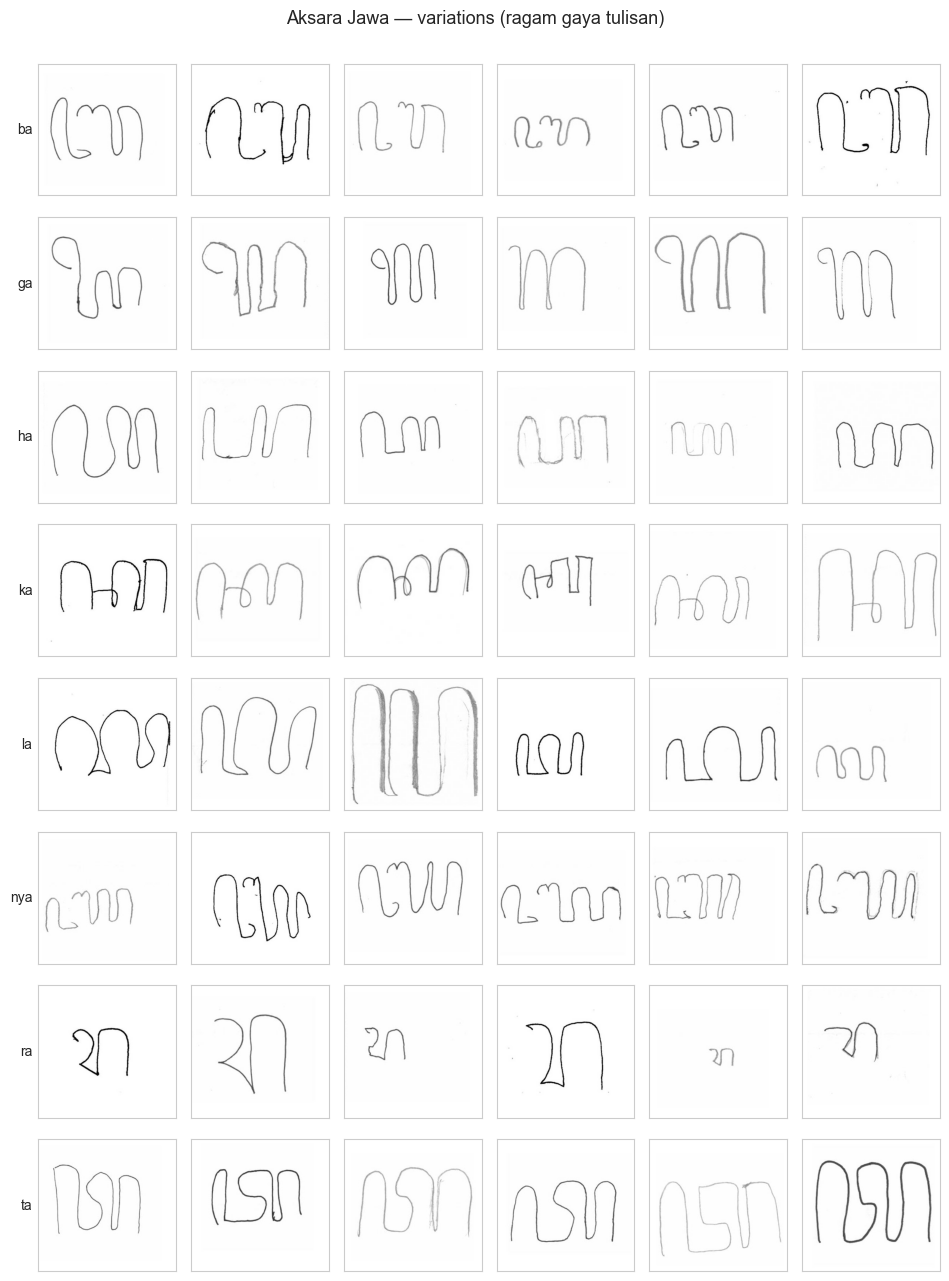

In [12]:
n_samples = 6
consonants_var = sorted([p.name for p in VARIATIONS.iterdir() if p.is_dir()])

fig, axes = plt.subplots(len(consonants_var), n_samples,
                          figsize=(1.6 * n_samples, 1.6 * len(consonants_var)))

for i, cons in enumerate(consonants_var):
    folder = VARIATIONS / cons
    files = sorted([f for f in folder.iterdir() if f.suffix.lower() in IMG_EXT])
    picks = random.sample(files, k=min(n_samples, len(files))) if files else []
    for j in range(n_samples):
        ax = axes[i][j] if len(consonants_var) > 1 else axes[j]
        if j < len(picks):
            ax.imshow(Image.open(picks[j]), cmap='gray')
        else:
            ax.axis('off')
        if j == 0:
            ax.set_ylabel(cons, fontsize=10, rotation=0, ha='right', va='center')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Aksara Jawa — variations (ragam gaya tulisan)', y=1.001, fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'gallery_variations.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Perbandingan `all_class` vs `variations` (konsonan yang sama)

Untuk 8 konsonan di `variations` (ba, ga, ha, ka, la, nya, ra, ta), berapa total citra mereka di `all_class` (digabung semua vokal)?

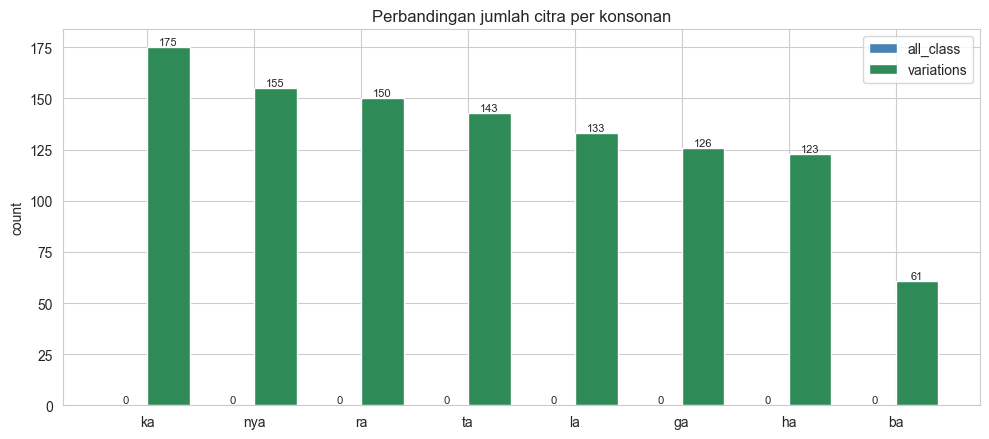

,consonant,all_class (semua vokal),variations
0,ka,0,175
1,nya,0,155
2,ra,0,150
3,ta,0,143
4,la,0,133
5,ga,0,126
6,ha,0,123
7,ba,0,61


In [13]:
var_consonants = df_var['consonant'].tolist()
all_class_sum = df_all.groupby('consonant')['count'].sum()

compare = pd.DataFrame({
    'consonant': var_consonants,
    'all_class (semua vokal)': [all_class_sum.get(c, 0) for c in var_consonants],
    'variations': df_var.set_index('consonant').loc[var_consonants, 'count'].values,
})

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(compare))
w = 0.4
ax.bar(x - w/2, compare['all_class (semua vokal)'], w, label='all_class', color='steelblue')
ax.bar(x + w/2, compare['variations'], w, label='variations', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(compare['consonant'])
ax.set_title('Perbandingan jumlah citra per konsonan')
ax.set_ylabel('count')
ax.legend()
for i in range(len(compare)):
    ax.text(i - w/2, compare['all_class (semua vokal)'].iloc[i],
            int(compare['all_class (semua vokal)'].iloc[i]), ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, compare['variations'].iloc[i],
            int(compare['variations'].iloc[i]), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'all_class_vs_variations.png', dpi=120)
plt.show()

compare

## 9. Ringkasan

File output di `results_jawa_eda/`:
- `all_class_per_class.csv`, `variations_per_class.csv`
- `all_class_by_axis.png`, `all_class_heatmap.png`
- `variations_distribution.png`
- `image_properties.png`
- `gallery_all_class.png`, `gallery_variations.png`
- `all_class_vs_variations.png`

In [14]:
print('=== RINGKASAN AKSARA JAWA ===')
print(f'all_class : {len(df_all)} kelas (vokal×konsonan), {df_all["count"].sum():,} citra')
print(f'            {df_all["vowel"].nunique()} vokal × {df_all["consonant"].nunique()} konsonan')
print(f'            imbalance ratio: {df_all["count"].max()/df_all["count"].min():.2f}x')
print(f'variations: {len(df_var)} konsonan, {df_var["count"].sum():,} citra')
print(f'            imbalance ratio: {df_var["count"].max()/df_var["count"].min():.2f}x')
print()
print(f'Total citra Jawa keseluruhan: {df_all["count"].sum() + df_var["count"].sum():,}')

=== RINGKASAN AKSARA JAWA ===
all_class : 120 kelas (vokal×konsonan), 12,191 citra
            6 vokal × 20 konsonan
            imbalance ratio: 33.10x
variations: 8 konsonan, 1,066 citra
            imbalance ratio: 2.87x

Total citra Jawa keseluruhan: 13,257
